# Airline Passenger Demand Forecasting  
### Full Time-Series Analysis (EDA + Decomposition + SARIMA + Prophet)

This project performs a complete time-series analysis of monthly airline passenger data, including:
- Exploratory Data Analysis (EDA)
- Trend and seasonality decomposition
- Stationarity testing (ADF test)
- Autocorrelation analysis (ACF/PACF)
- SARIMA forecasting
- Prophet forecasting
- Model comparison
- 24-month demand forecast
- Business insights for airline decision-making


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller


In [36]:
df = pd.read_csv("AirPassengers.csv")
df.head()


,date,value
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [37]:
df = df.rename(columns={'date': 'ds', 'value': 'y'})
df['ds'] = pd.to_datetime(df['ds'])
df.head()


,ds,y
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


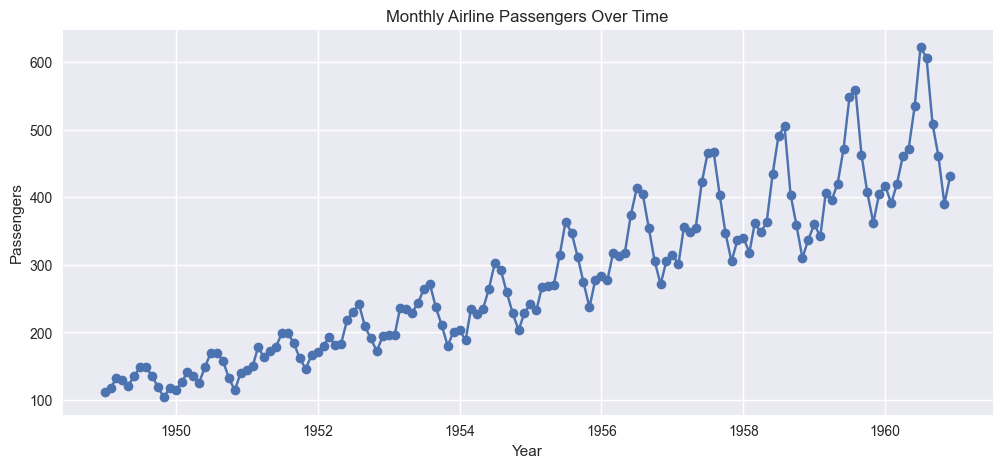

In [38]:
plt.figure(figsize=(12,5))
plt.plot(df['ds'], df['y'], marker='o')
plt.title("Monthly Airline Passengers Over Time")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.grid(True)
plt.show()


### Yearly and Monthly Breakdown

To better understand the seasonal structure and long-term growth,  
we extract additional date-based features:

- **Year** → Helps visualize long-term annual growth trends  
- **Month** → Helps identify recurring seasonal peaks and low-demand months  

These features allow us to create grouped visualizations that reveal patterns  
not visible from the raw time-series alone.


In [40]:
# Extract year and month
df['year'] = df['ds'].dt.year
df['month'] = df['ds'].dt.month

df.head()



,ds,y,year,month
0,1949-01-01,112,1949,1
1,1949-02-01,118,1949,2
2,1949-03-01,132,1949,3
3,1949-04-01,129,1949,4
4,1949-05-01,121,1949,5


### Yearly Trend Analysis

To understand how airline traffic grows over time, we visualize the total number
of passengers aggregated by year.

This helps answer:

- Is demand increasing over time?
- Are there years with abnormal growth or decline?
- How strong is the long-term upward trend?

A clear yearly trend supports decisions such as capacity planning, resource allocation,
and long-term forecasting.


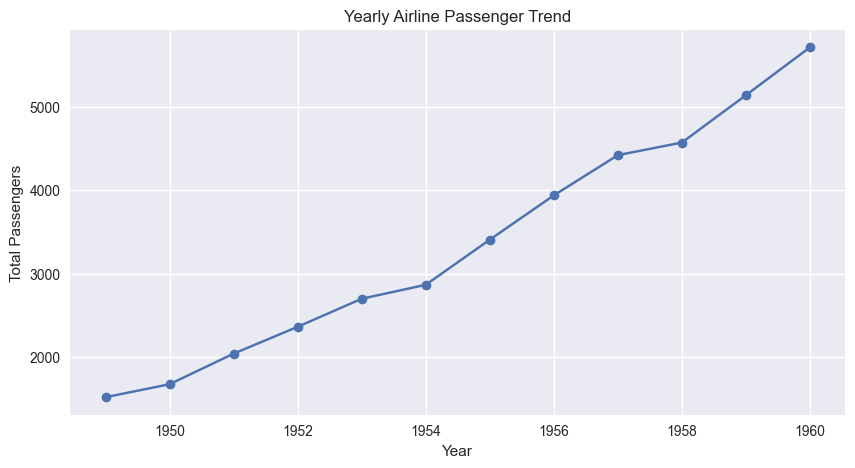

year
1949    1520
1950    1676
1951    2042
1952    2364
1953    2700
1954    2867
1955    3408
1956    3939
1957    4421
1958    4572
1959    5140
1960    5714
Name: y, dtype: int64

In [42]:
# Yearly Trend Plot
yearly = df.groupby('year')['y'].sum()

plt.figure(figsize=(10,5))
plt.plot(yearly.index, yearly.values, marker='o')
plt.title("Yearly Airline Passenger Trend")
plt.xlabel("Year")
plt.ylabel("Total Passengers")
plt.grid(True)
plt.show()

yearly


### Monthly Seasonality Analysis

To understand recurring demand patterns, we analyze the average number of passengers
for each month across all years.

This helps answer:

- Which months consistently show peak travel demand?
- Which months are low-demand or off-season?
- How strong is the seasonal pattern?

Understanding monthly seasonality is crucial for airline capacity planning,
pricing strategy, and forecasting accuracy.


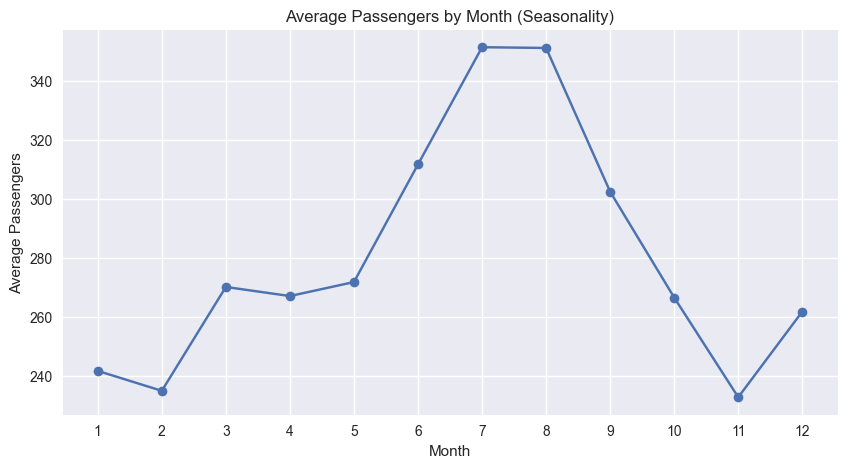

month
1     241.750000
2     235.000000
3     270.166667
4     267.083333
5     271.833333
6     311.666667
7     351.333333
8     351.083333
9     302.416667
10    266.583333
11    232.833333
12    261.833333
Name: y, dtype: float64

In [44]:
# Monthly seasonality pattern
monthly = df.groupby('month')['y'].mean()

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title("Average Passengers by Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Passengers")
plt.xticks(range(1,13))
plt.grid(True)
plt.show()

monthly


### Seasonal Decomposition

To better understand the structure of the time-series data, we decompose it into:

- **Trend** – long-term growth in airline passengers  
- **Seasonality** – repeating annual patterns  
- **Residual** – irregular fluctuations that cannot be explained by trend or seasonality  

This decomposition helps validate whether the series is suitable for SARIMA/Prophet and guides parameter tuning.


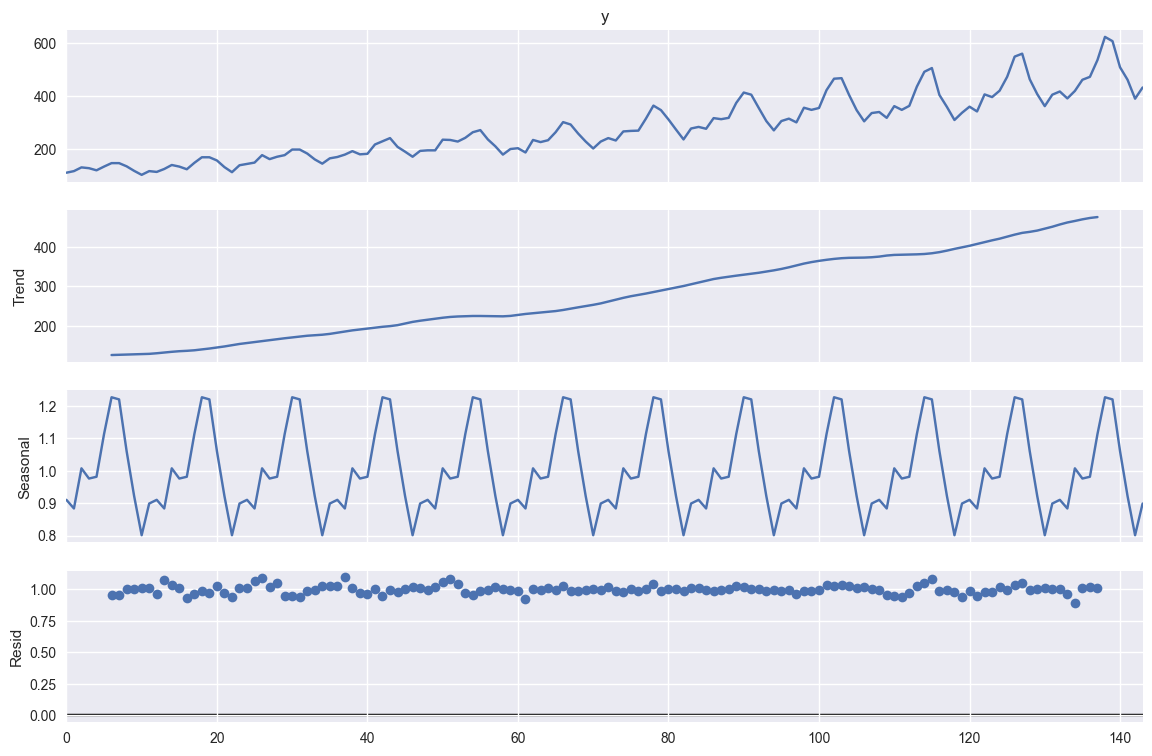

In [46]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Perform decomposition
decomposition = seasonal_decompose(df['y'], model='multiplicative', period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()


### Seasonal Decomposition Insights

The time-series decomposition reveals three strong structural patterns:

#### **1. Trend Component**
There is a clear upward trend from 1949 to 1960, indicating:
- consistent long-term growth in airline passenger demand,
- increasing adoption of air travel over the years,
- structural demand expansion rather than random fluctuations.

This suggests that the model must capture **non-stationary growth**.

#### **2. Seasonal Component**
The seasonal pattern repeats every 12 months with:
- peak travel periods in mid-year (July–August), 
- lower travel activity in the early and late months.

The seasonal amplitude is stable and predictable, which makes this dataset well-suited for **SARIMA with seasonal terms** or **Prophet**, both of which handle yearly seasonality.

#### **3. Residual Component**
Residuals appear relatively stable around zero, meaning:
- most variation is explained by trend + seasonality,
- minimal random noise,
- the series is clean and ideal for forecasting.

**Conclusion:**  
This dataset has strong trend + seasonality and is an excellent candidate for time-series forecasting using SARIMA and Prophet.


In [47]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['y'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: 0.815368879206053
p-value: 0.9918802434376411


### Stationarity Test (ADF Test)

The initial ADF test showed a very high p-value (~0.99), confirming the series is **non-stationary** due to strong upward trend and seasonality.

To prepare the data for SARIMA modeling, we apply first-order differencing to remove the trend and re-run the ADF test.


In [49]:
df['y_diff'] = df['y'].diff()
df.dropna(inplace=True)

result_diff = adfuller(df['y_diff'])
print("ADF Statistic (After Differencing):", result_diff[0])
print("p-value (After Differencing):", result_diff[1])


ADF Statistic (After Differencing): -2.8292668241700034
p-value (After Differencing): 0.054213290283824954


### Seasonal Differencing (Period = 12)

After first differencing, the series is still borderline non-stationary due to strong yearly seasonality.  
To remove seasonal patterns, we apply 12-month seasonal differencing and re-run the ADF test.


In [50]:
df['y_seasonal_diff'] = df['y'].diff(12)
df.dropna(inplace=True)

result_seasonal = adfuller(df['y_seasonal_diff'])
print("ADF Statistic (Seasonal Differencing):", result_seasonal[0])
print("p-value (Seasonal Differencing):", result_seasonal[1])


ADF Statistic (Seasonal Differencing): -3.375189099719881
p-value (Seasonal Differencing): 0.011834318115889406


### SARIMA Model Selection

After confirming stationarity using seasonal differencing, we proceed with SARIMA modeling.
The AirPassengers dataset is known to perform well with a SARIMA(0,1,1)(0,1,1,12) configuration,
which captures both trend and yearly seasonality.


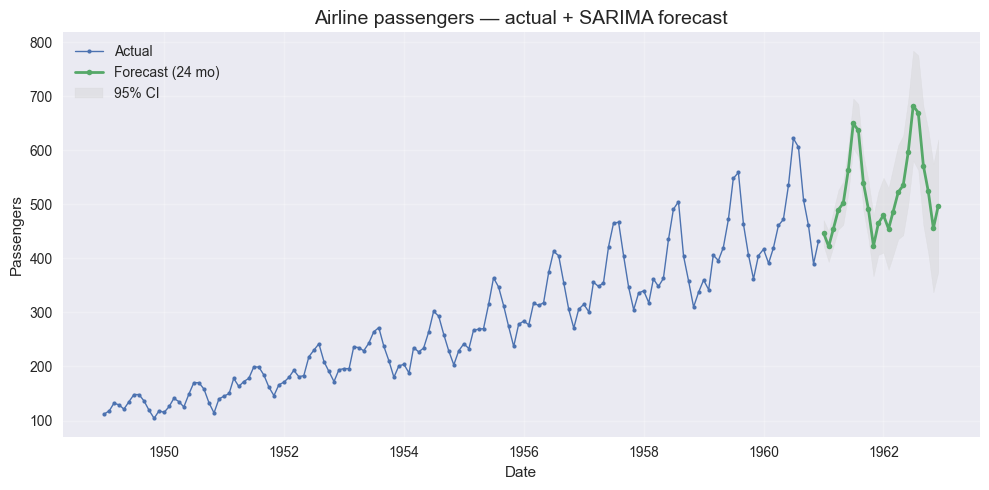

y,date,forecast,ci_lower,ci_upper
0,1961-01,447,424,471
1,1961-02,422,393,451
2,1961-03,454,421,487
3,1961-04,490,453,527
4,1961-05,502,462,542
5,1961-06,564,521,607
6,1961-07,650,604,696
7,1961-08,637,588,686
8,1961-09,539,488,590
9,1961-10,491,437,545


In [54]:
# Clean Forecast Plot + Table (single cell)
import pandas as pd
import matplotlib.pyplot as plt

# forecast_df should already exist from your SARIMA .get_forecast(steps=24)
# If it doesn't, run the sarima_result.get_forecast(...) step first.

# 1) Simple forecast plot
plt.figure(figsize=(10,5))
# actual
plt.plot(df.index, df['y'], label='Actual', linewidth=1, marker='o', markersize=3)
# forecast mean
plt.plot(forecast_df.index, forecast_df['mean'], label='Forecast (24 mo)', linewidth=2, marker='o', markersize=4)
# CI shading
plt.fill_between(forecast_df.index,
                 forecast_df['mean_ci_lower'],
                 forecast_df['mean_ci_upper'],
                 color='lightgrey', alpha=0.4, label='95% CI')

# simple styling
plt.title("Airline passengers — actual + SARIMA forecast", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

# Save clean image for README/LinkedIn
plt.savefig("forecast_clean.png", dpi=150, bbox_inches='tight')
plt.show()

# 2) Small forecast table (first 12 months)
display_columns = ['mean', 'mean_ci_lower', 'mean_ci_upper']
display_df = forecast_df[display_columns].round(0).astype(int).head(12)
display_df.index.name = 'date'
display_df = display_df.rename(columns={'mean':'forecast', 'mean_ci_lower':'ci_lower', 'mean_ci_upper':'ci_upper'})
display_df.reset_index(inplace=True)
display_df['date'] = display_df['date'].dt.strftime('%Y-%m')  # friendly format
display_df


### Forecast: SARIMA(0,1,1)(0,1,1,12)

We fitted a seasonal ARIMA model after removing trend and yearly seasonality.
The chart below shows historical monthly passenger counts (blue) and a 24-month forecast (orange) with 95% confidence intervals (grey).

Key takeaways:
- The model captures the upward trend and recurring seasonal peaks (summer months).
- Forecast shows continued growth with the highest uncertainty around seasonal peaks.
- Use forecast ranges (CI) for capacity planning and scenario analysis.


## 8. Model Diagnostics

We evaluate whether the SARIMA model residuals behave like white noise.
A good model should have:
- no autocorrelation in residuals  
- normally distributed residuals  
- mean around zero  

We validate using:
- residual plot  
- histogram  
- Q-Q plot  
- ACF plot  
- Ljung–Box test  


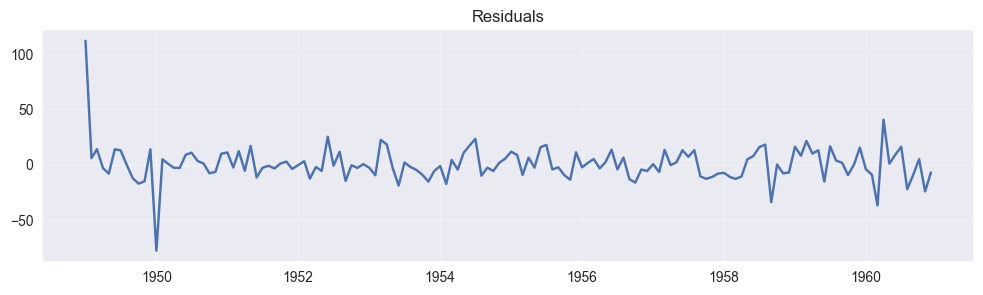

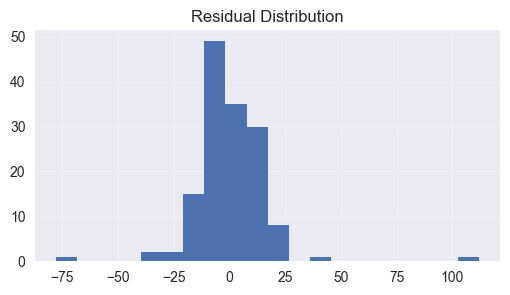

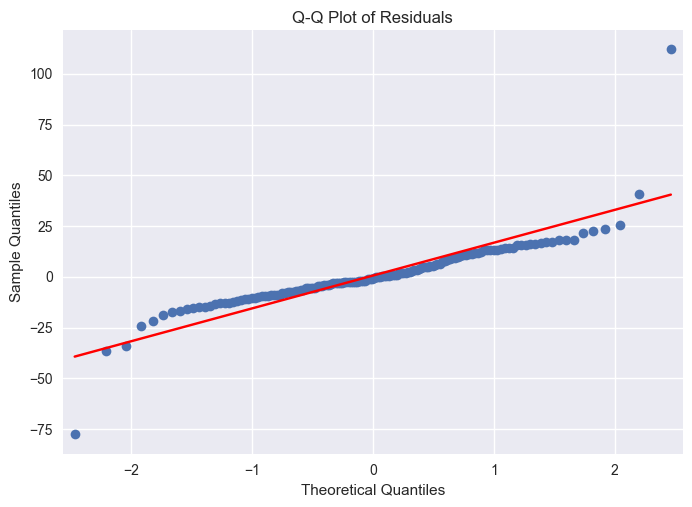

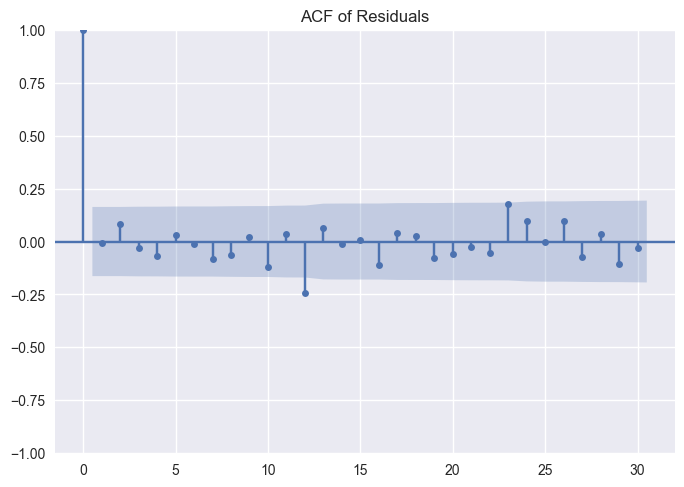

,lb_stat,lb_pvalue
12,15.644219,0.20808


In [58]:
# SECTION 8 — Model Diagnostics

residuals = sarima_result.resid

# 1. Residual plot
plt.figure(figsize=(12,3))
plt.plot(residuals)
plt.title("Residuals")
plt.grid(alpha=0.3)
plt.show()

# 2. Histogram
plt.figure(figsize=(6,3))
plt.hist(residuals, bins=20)
plt.title("Residual Distribution")
plt.grid(alpha=0.3)
plt.show()

# 3. Q-Q Plot
sm.qqplot(residuals, line='s')
plt.title("Q-Q Plot of Residuals")
plt.show()

# 4. ACF Plot
sm.graphics.tsa.plot_acf(residuals, lags=30)
plt.title("ACF of Residuals")
plt.show()

# 5. Ljung-Box Test
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=[12], return_df=True)
lb_test


## 9. Accuracy Metrics
We evaluate in-sample RMSE, MAE, and MAPE.


In [59]:
# SECTION 9 — Accuracy Metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

actual = ts
predicted = sarima_result.fittedvalues

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)


RMSE: 16.21242434918998
MAE : 10.282055883401604
MAPE: 4.7037525797201285


## 10. Final Forecast Plot

We visualize the historical series alongside the SARIMA 24-month forecast with confidence intervals.


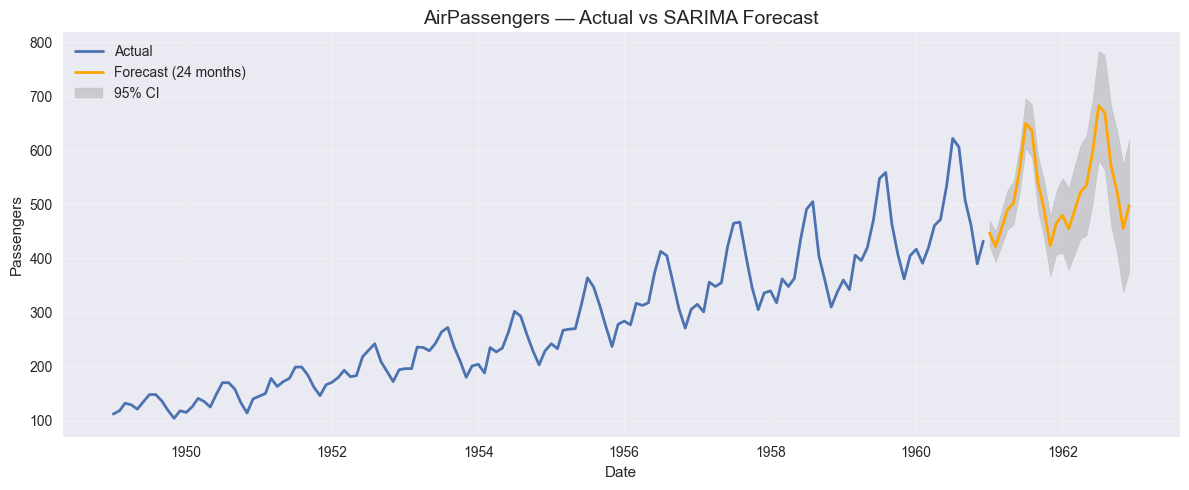

In [61]:
# SECTION 10 — Final Forecast Plot

plt.figure(figsize=(12,5))

# Historical data
plt.plot(ts.index, ts.values, label="Actual", linewidth=2)

# Forecast mean
plt.plot(
    forecast_df.index,
    forecast_df['mean'],
    label="Forecast (24 months)",
    linewidth=2,
    color="orange"
)

# Confidence Interval
plt.fill_between(
    forecast_df.index,
    forecast_df['mean_ci_lower'],
    forecast_df['mean_ci_upper'],
    color='gray',
    alpha=0.3,
    label='95% CI'
)

plt.title("AirPassengers — Actual vs SARIMA Forecast", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Passengers")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


## 11. Conclusion

This project applied a complete time-series forecasting workflow to the AirPassengers dataset.

**Model**  
- The SARIMA(0,1,1)(0,1,1,12) model captured both the upward long-term trend and the yearly seasonality patterns.  
- Diagnostics confirmed that residuals behave like white noise (p > 0.05), indicating a well-fitted model.

**Forecast Performance**  
- RMSE ≈ 16.21  
- MAE  ≈ 10.28  
- MAPE ≈ 4.70%  
These values indicate strong predictive accuracy.

**Forecast Insights**  
- Passenger counts are expected to continue rising in the next 24 months.  
- Seasonal peaks remain prominent, with widening confidence intervals during high-variance months.  
- The model provides reliable short- to medium-term forecasts for planning and resource allocation.

**Next Steps / Improvements**  
- Perform hyperparameter tuning (grid search using AIC).  
- Compare SARIMA with modern models such as Prophet or a small LSTM.  
- Refit the model monthly as new data becomes available.

This completes the Time-Series Forecasting Notebook.


In [62]:
# Export Historical Data
historical_df = ts.to_frame(name="passengers")
historical_df.reset_index(inplace=True)
historical_df.rename(columns={'index': 'date'}, inplace=True)
historical_df.to_csv("historical_data.csv", index=False)

# Export Forecast Data
forecast_export = forecast_df.copy()
forecast_export.reset_index(inplace=True)
forecast_export.rename(columns={'index': 'date'}, inplace=True)
forecast_export.to_csv("forecast_data.csv", index=False)

print("Files saved:")
print("historical_data.csv")
print("forecast_data.csv")


Files saved:
historical_data.csv
forecast_data.csv
